<a href="https://colab.research.google.com/github/nawroz-m/ML_learning/blob/BigImgSingnal/forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
from google.colab import drive
import pandas as pd
import torch
from torch import nn
import numpy as np
import sklearn


In [2]:
# load the dataset
drive.flush_and_unmount()
drive.mount('/content/drive')

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive


In [3]:
path = "/content/drive/MyDrive/Big Img Sig/Forest/ForestDataset"
train_dataset = pd.read_csv(f'{path}/train.csv', sep=",")


In [140]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
learning_rate = 0.0005
device

'cpu'

In [141]:
# Dataset reader class
class Dataset(torch.utils.data.Dataset):
  def __init__(self, csv_path):
    self.df = pd.read_csv(csv_path, sep=',')
    self.input_col = self.df.columns.drop(self.df.columns[-1])
    self.output_col = self.df.columns[-1]

  def __len__(self):
    return len(self.df)
  def __getitem__(self, index):
    row = self.df.iloc[index]
    features = torch.tensor(row[self.input_col].values, dtype=torch.float32)
    attribute = torch.tensor(row[self.output_col], dtype=torch.float32)

    return features, attribute


In [142]:
# load the dataset
train_data = Dataset(f'{path}/train.csv')
test_data = Dataset(f'{path}/test.csv')

In [143]:
validate_data = Dataset(f'{path}/val.csv')

In [144]:
# dataloader
train_data_loader = torch.utils.data.DataLoader(dataset=train_data,
                                                batch_size=32,
                                                shuffle=True,
                                                drop_last=True,
                                                num_workers=2)
test_data_loader = torch.utils.data.DataLoader(dataset=test_data,
                                                batch_size=32,
                                                shuffle=True,
                                                drop_last=True,
                                                num_workers=2)

In [145]:
# Define the model class
class Network(nn.Module):
  def __init__(self):
    super(Network, self).__init__()
    # initialize the layers
    self.linear_relu_seq = nn.Sequential(
      nn.Linear(in_features=54, out_features=128),
      nn.ReLU(),

      nn.Linear(in_features=128, out_features=64),
      nn.ReLU(),

      nn.Linear(in_features=64,  out_features=32),
      nn.ReLU(),
      # output layer
      nn.Linear(in_features=32, out_features=1)
    )
  def forward(self, x):
    return self.linear_relu_seq(x)

# Move the model in the device
model = Network().to(device)
model

Network(
  (linear_relu_seq): Sequential(
    (0): Linear(in_features=54, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [146]:
# define the loss and optimizer
loss_fun = nn.functional.mse_loss
optimizer_fun = torch.optim.Adam(params=model.parameters(), lr=learning_rate)

In [147]:
# Train the model
def train(dataloader, model, loss_fun, optimizer):
  train_loss, total_loss = 0, 0
  model.train()
  for batch, (X, y) in enumerate(dataloader):
    X, y = X.to(device), y.to(device)
    y = y.unsqueeze(1)

    # compute the prediction error
    pred = model(X)
    loss = loss_fun(input=pred, target=y)
    # backpropaget
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    total_loss += loss.item()
    if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{len(dataloader.dataset):>5d}]")
  train_loss = total_loss/len(dataloader)

  return train_loss, total_loss

In [148]:
# Evaluate the mode
def evaluate_model(dataloader, mode, loss_fun):
  model.eval()
  total_loss = 0
  y_pred = []
  with torch.no_grad():
    for X, y in dataloader:
      X, y = X.to(device), y.to(device)
      y = y.unsqueeze(1)
      pred = mode(X)
      # comput the loss
      loss = loss_fun(input=pred, target=y)
      total_loss += loss.item()
      y_pred.append(pred.cpu())
  avg_loss = total_loss/len(dataloader)
  return avg_loss, y_pred

In [ ]:
epoch = 20
train_loss= []
avg_loss= []
labels = []
for t in range(epoch):
  print(f'Epoch {t+1} ----------------------------- ')
  tr_loss, total_loss = train(train_data_loader, model, loss_fun, optimizer_fun)
  train_loss.append(tr_loss)
  loss, label = evaluate_model(test_data_loader, model, loss_fun)
  print(f'Validation loss: \n val_loss: {loss}')
  avg_loss.append(loss)
  labels.append(label)

<Axes: >

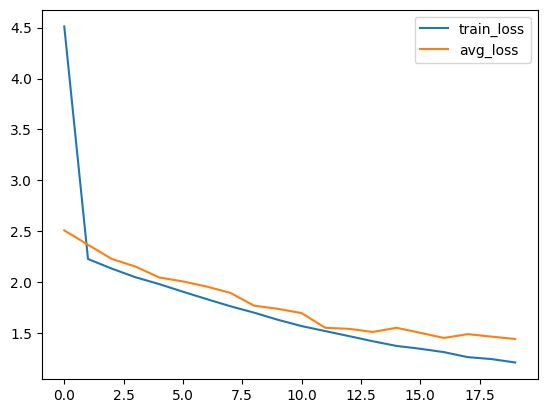

In [150]:
pd.DataFrame({'train_loss': train_loss, 'avg_loss': avg_loss}).plot()
